# Welcome to the OHDSI tutorial for Five Safes TES!
## Contents
- Introduction
- Workbench
    - Log in
    - Check that you can connect to Five Safes TES
- Incidence and prevalence
    - Design your analysis
    - Send off a task
    - Collect results
    - Visualise results

## Introduction

This Jupyter notebook is a tutorial for running analysis through Five Safes TES (5s-TES).
You can use a python package, the 5S-TES Workbench, to send tasks to a 5s-TES submission layer and collect your results.
This notebook will use the workbench to submit tasks that use Darwin EU libraries to analyse OMOP data.

By the end of this notebook, you will have:
1. Connected to 5s-TES with the workbench
2. Defined an analysis using a Darwin EU library
3. Submitted it to the TES server as a TES message
4. Fetched the outputs of your analysis and visualised them.

This notebook has some "cells" which is a group of executable Python code. To run the code/cell, you can simply click on the cell and press the play button or pressing `Shift+Enter`.

Before each cell, we will provide a description of the task and the expected outputs. The full guide on how to run Workbench is available [here](https://docs.federated-analytics.ac.uk/tutorials/submit-to-5s-tes/workbench).

Start by loading the code supporting this notebook. Select the cell below and run it.

In [1]:
from ui import IncidencePrevalenceForm, WorkbenchForm
from i_p_utils import load_5s_tes_incidence_result, plot_incidence_results

## Workbench

The 5S-TES Workbench is a Python library that stores the configuration necessary to connect to 5s-TES, and can be used to submit tasks as TES messages and collect your results.

### Log in
To use the Workbench, you need to supply some credentials.
For this workshop, we have pre-defined some of the connection parameters.

<details>
    <summary>Configuration details</summary>


- `project`: The name of the project you are working on, e.g. "OHDSIDemo".
- `tres`: The TREs you want to run the analysis on, e.g. "Nottingham TRE 01" and "Nottingham TRE 02".
- `tes_base_url`: The base URL of the TES server. For 5S-TES, this is the Submission layer API endpoint.
- `keycloak_url`: The URL of the Keycloak server.
- `client_id` and `client_secret`: The client ID and client secret for the OIDC Keycloak server.
- `username` and `password`: Your username and password for 5S-TES Submission layer.
</details>

If you run the cell below, you will be shown a form.
This form handles initialisation of the workbench for you; you only need to enter your username and password.

In [2]:
wb_form = WorkbenchForm()

wb_form.display()

### Check your connection

Run the next cell to check you're connecting to 5s-TES.
If your credentials are correct, the cell will log some messages prefixed with `INFO  |`.
If it doesn't work, you'll get a big scary error message.
Don't worry, just check your credentials!

In [3]:
wb_form.check_connection()

INFO | Template registered: 'hello_world'
INFO | Template registered: 'custom'
INFO | Template registered: 'simple_sql'
INFO | Template registered: 'bunny'
INFO | Template registered: 'analysis'
INFO | Validation successful
INFO | Config: project='OHDSIDemo' tes_base_url='https://api.5s-tes.federated-research.com/' tres=['Nottingham TRE 01', 'Nottingham TRE 02']
INFO | Auth mode: AuthMode.CREDENTIALS
INFO | Fetching Keycloak ID token for STS exchange...
INFO | Requesting Keycloak token from https://drs-core-identity.azurewebsites.net/realms/Dare-Control/protocol/openid-connect/token
INFO | Keycloak token fetched successfully
INFO | Exchanging bearer token for MinIO credentials via STS (https://api.s3.5s-tes.federated-research.com)
INFO | MinIO client initialized (endpoint=https://api.s3.5s-tes.federated-research.com, secure=True)
INFO | Child task info: 1857, TRE: Nottingham TRE 01, status: Completed
INFO | Found 1 result object(s) for task 1857
INFO | Downloading result object: 1857/s

## Incidence and Prevalence

The [IncidencePrevalence library](https://darwin-eu.github.io/IncidencePrevalence/) from [Darwin EU](https://www.darwin-eu.org/index.php) estimates incidence or prevalence of an outcome on data in the [OMOP-CDM](https://ohdsi.github.io/CommonDataModel/). We have packaged some of the library's functions and a basic cohort definition so that users can run incidence and prevalence analyses with 5s-TES.
The analysis you define will run on the OMOP databases held in two TREs (Nottingham TRE 01 and Nottingham TRE 02).
These databases hold synthetic OMOP data generated using the [Delphi 2M model](https://www.nature.com/articles/s41586-025-09529-3).

To make sure everyone can complete the analysis during the workshop, a simplified analysis has been presented, but more complex analysis can be defined (see [the toolkit](https://github.com/Health-Informatics-UoN/omop-r-toolkit/#incidence-and-prevalence) for more information).

<details>
    <summary>How the analysis workflow runs</summary>


This analysis runs multiple R scripts under the hood.

1. The first script defines an outcome cohort using [CDMConnector](https://darwin-eu.github.io/CDMConnector/reference/generateConceptCohortSet.html) (thanks again Darwin EU!)
2. The second script defines a denominator cohort, which for this analysis is everyone aged 0 to 150 observed since 1990, and estimates incidence for the outcome.
3. Cleans up the cohort tables to be polite    
</details>

### Design your analysis

Running the cell beneath this text will present you with a form to design your incidence analysis.
The form has text boxes for the details of your analysis.

#### Researcher name
Your name!
You can put someone else's if you like, as long as you remember it.
The pre-filled value is not the King in the North, but the epidemiologist of Broad Street water pump fame.

#### Outcome cohort name
A name for your outcome cohort. This and the denominator cohort name need to be in `snake_case`, e.g. "skin_cancer_test_denominator" and "skin_cancer_test"

#### Concept sets
To do this, first, we need to define the concept set:

A concept set is a named list of unique numbers called concept IDs that together define the group of patients you want to study. For example, because the concept ID for skin cancer (or neoplasm) is 139750, I could define the concept set for skin cancer as `{"neoplasm": [139750]}`. For diabetes, the concept set could be `{"diabetes": [4131907,4220821]}`.

To build a concept set for yourself, 
1. Go to https://athena.ohdsi.org
2. Search for your condition (e.g., "skin cancer")
3. Filter by Standard concepts and Condition domain
4. Copy the number(s) in the Concept ID column
5. Put the number(s) in the square brackets, e.g. [139750, 609278, 4133025], and name the concept set, e.g. "skin cancer"

#### Denominator cohort name
A name for your denominator cohort.

In [4]:
task_form = IncidencePrevalenceForm()
task_form.display()

### Send off a task
To finish sending your analysis, run the cell below to build the TES task and submit it to the TES server.
The code in this cell uses the login form above to set up a Workbench instance ready for task submission, then uses one of its `build_tes` methods and the information you provided to make a TES message.

Finally, this submits the task to the submission layer.
Each time you run this cell, it will build a new TES task and submit it to the 5s-TES submission layer, so please don't run it over and over!

If this cell executes successfully, you will see some of the same validation messages you saw when checking your connection, followed by:
```
INFO | TES Task built successfully
INFO | TES payload:
```

After these lines, you will see your [TES message](https://ga4gh.github.io/task-execution-schemas/docs/#tag/TaskService/operation/CreateTask) describing your analysis.
This is what the TRE uses to understand what you want!
If you want to read it, you'll be able to find your analysis parameters in there.

Finally, you should see

```
INFO | Task submitted successfully! ID: <some integer>
```

This ID is the task ID on the server.
You can check it on [the submission layer](https://5s-tes.federated-research.com/Submission/GetAllSubmissions).
It will probably take about 7 minutes to run, then you have to wait for egress, so now might be a good time to see if we've provided refreshments!

In [5]:
# Build the TES task - should not be changed
wb = wb_form.validate()
wb.build_tes.custom(
    name=f"OHDSI - {task_form.researcher_name}",
    description="Darwin EU - Incidence prevalence demo analysis",
    executors=task_form.render_executor(),
    outputs=[
        {
            "name": "Analysis Results Location",
            "description": "Analysis Results Location",
            "url": "s3://",
            "path": "/outputs",
            "type": "DIRECTORY",
        }
    ],
)

INFO | Template registered: 'hello_world'
INFO | Template registered: 'custom'
INFO | Template registered: 'simple_sql'
INFO | Template registered: 'bunny'
INFO | Template registered: 'analysis'
INFO | Validation successful
INFO | Config: project='OHDSIDemo' tes_base_url='https://api.5s-tes.federated-research.com/' tres=['Nottingham TRE 01', 'Nottingham TRE 02']
INFO | Auth mode: AuthMode.CREDENTIALS
INFO | Building TES task from template: 'custom'
INFO | Resolving template: 'custom'
INFO | TES Task built successfully
INFO | TES payload:
{
   "name": "OHDSI - John Snow",
   "description": "Darwin EU - Incidence prevalence demo analysis",
   "outputs": [
      {
         "url": "s3://",
         "path": "/outputs",
         "type": "DIRECTORY",
         "name": "Analysis Results Location",
         "description": "Analysis Results Location"
      }
   ],
   "executors": [
      {
         "image": "ghcr.io/health-informatics-uon/omop-r-tools:sha-9aa526d",
         "command": [
         

In [6]:
# Submit the TES task - should not be changed
wb.submit()

INFO | Fetching token from Keycloak...
INFO | Requesting Keycloak token from https://drs-core-identity.azurewebsites.net/realms/Dare-Control/protocol/openid-connect/token
INFO | Keycloak token fetched successfully
INFO | Task submitted successfully! ID: 3065


'3065'

### Collect your results
5s-TES tasks finish by writing results to a file, which you can then collect.
Once the outputs of your task are approved by TRE's Egress officer, you can retrieve them by running the following cell.

By default, without any parameters, function `fetch_outputs` will try fetching the outputs related to the latest task, which you just submitted, from all targeted TREs and save them in the `output` directory next to this notebook.

You can also fetch outputs from a specific task by passing the `task_id` parameter to the function. For example, to fetch the outputs from task with `task_id = 1823`, you can run: `wb.fetch_outputs(task_id=1823)`

In [7]:
incidence_output = wb.fetch_outputs()

INFO | Fetching Keycloak ID token for STS exchange...
INFO | Requesting Keycloak token from https://drs-core-identity.azurewebsites.net/realms/Dare-Control/protocol/openid-connect/token
INFO | Keycloak token fetched successfully
INFO | Exchanging bearer token for MinIO credentials via STS (https://api.s3.5s-tes.federated-research.com)
INFO | MinIO client initialized (endpoint=https://api.s3.5s-tes.federated-research.com, secure=True)
INFO | Child task info: 3057, TRE: Nottingham TRE 01, status: Completed
INFO | Found 1 result object(s) for task 3057
INFO | Downloading result object: 3057/incidence.csv
INFO | Downloaded 3057/incidence.csv -> /Users/jamesmitchell-white/Documents/GitHub/5s-TES-notebooks/Darwin-EU/output/Nottingham TRE 01/3057/incidence.csv
INFO | Child task info: 3058, TRE: Nottingham TRE 02, status: Completed
INFO | Found 1 result object(s) for task 3058
INFO | Downloading result object: 3058/incidence.csv
INFO | Downloaded 3058/incidence.csv -> /Users/jamesmitchell-whit

### Visualise results
The outputs of the analysis are comma-separated value (csv) files for tables in the [omopgenerics](https://darwin-eu.github.io/omopgenerics) `summarised_result` format.
This is a standard way of representing results in the Darwin EU ecosystem, so the files can be analysed in R using their libraries.
For this workshop, we have some utilities for these files in Python, but if you want to carry out some analysis we don't support here, you can still use the R libraries on the files.

Running the cell below will read the files into the notebook and wrangle them into the right shape for analysis.

In [8]:
incidence_results = load_5s_tes_incidence_result(incidence_output)

The result of this is a dictionary of `IncidenceResult`s: one result per TRE, with the TRE name as a key.
You can have a look at an individual `IncidenceResult` by asking for `incidence_results[<TRE name>]`.
An `IncidenceResult` has `.results` for a DataFrame of the incidence information, and methods for plotting.

The cell below uses the plotting methods to plot the incidence from each TRE as a scatter plot with bars to show the 95% confidence intervals.
The synthetic data probably don't have very high incidence for any given condition, so don't expect anything dramatic!

/Users/jamesmitchell-white/Documents/GitHub/5s-TES-notebooks/.venv/lib/python3.13/site-packages/incidence_prevalence/plots.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha="right")
/Users/jamesmitchell-white/Documents/GitHub/5s-TES-notebooks/.venv/lib/python3.13/site-packages/incidence_prevalence/plots.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=30, ha="right")


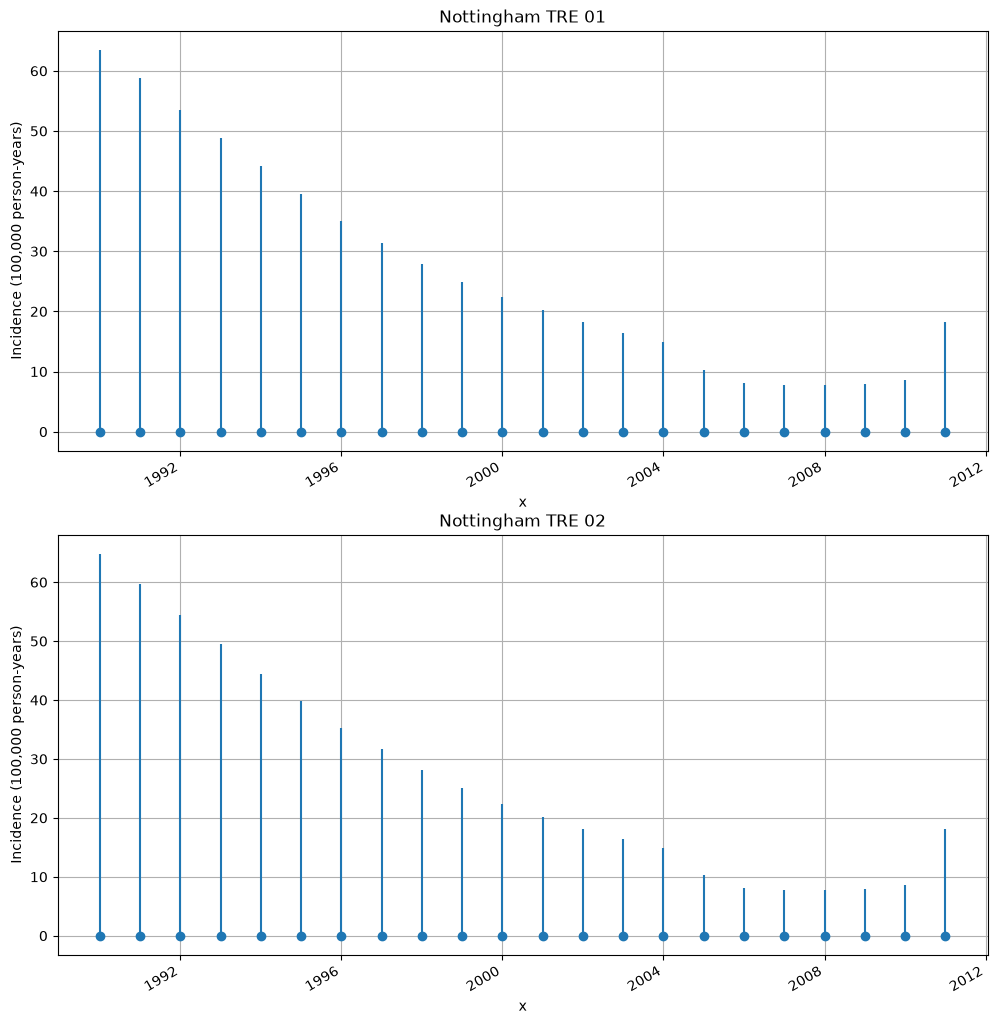

In [14]:
plot_incidence_results(incidence_results)